In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

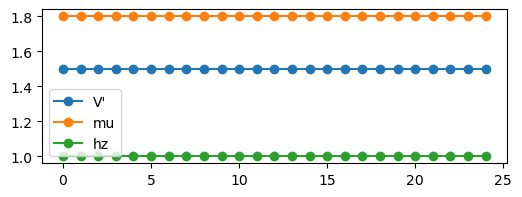

In [2]:
widthP = 25

X, Y = widthP, 100
lattice = Lattice(X, Y)

t = 1
T = 0.02

muS = 1.2 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.ones(lattice.X) * muP

hz0 = 1 * t
hz = np.ones_like(mu) * hz0

hx0 = 1 * t
hx = np.ones_like(mu) * hx0

hy0 = 1 * t
hy = np.ones_like(mu) * hy0


V0 = 1.5 * t
V_prime = V0 * np.ones(lattice.X)
# V_prime[:widthF+widthS] = 0 
U = None
V = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hz, '-o', label='hz')

plt.legend()

In [3]:
H = Hamiltonian(t, mu, lattice, 
                U=U, V_prime=V_prime, V=None,
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hy=hy)

In [4]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.1, atol=1e-3, maxiter=100, verbose=True, temperature=T)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.07780993320333615
Relative error: 77809933203.33615
Average old: 0j
Average: (1.1057132876753456e-18+1.2212453270876722e-17j)
F_xplus:
Absolute error: 0.01396686783559587
Relative error: 13966867835.595871
Average old: 0j
Average: (-2.4200909198032126e-19-5.341502703111918e-17j)
F_xmin:
Absolute error: 0.013966867835595568
Relative error: 13966867835.595568
Average old: 0j
Average: (-1.3059408923607092e-19+6.042620107985877e-17j)
F_yplus:
Absolute error: 0.051465064167681006
Relative error: 51465064167.68101
Average old: 0j
Average: (4.772043890772949e-17-1.1934897514720433e-17j)
F_ymin:
Absolute error: 0.051465064167681
Relative error: 51465064167.681
Average old: 0j
Average: (-4.4199024279553857e-17-1.7208456881689926e-17j)
Fuu_xplus:
Absolute error: 0.23847470212756147
Relative error: 2.384747021251767
Average old: (0.09999999999999999+0j)
Average: (0.05158374985742621-2.161244436320313e-18j)
Fuu_xmin:
Absolute error: 0.23847470212756153
Relative error: 2.38474

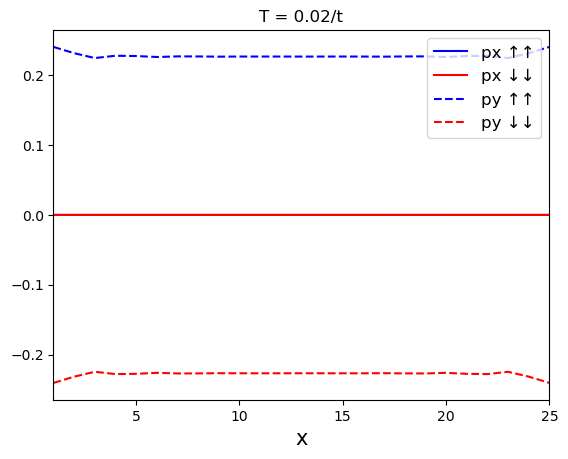

In [5]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
plt.plot(x, np.real(Fuu.px), label="px ↑↑", color='blue')
plt.plot(x, np.real(Fdd.px), label="px ↓↓", color='red')
plt.plot(x, np.imag(Fuu.py), "--", label="py ↑↑", color='blue')
plt.plot(x, np.imag(Fdd.py), "--", label="py ↓↓", color='red')
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")

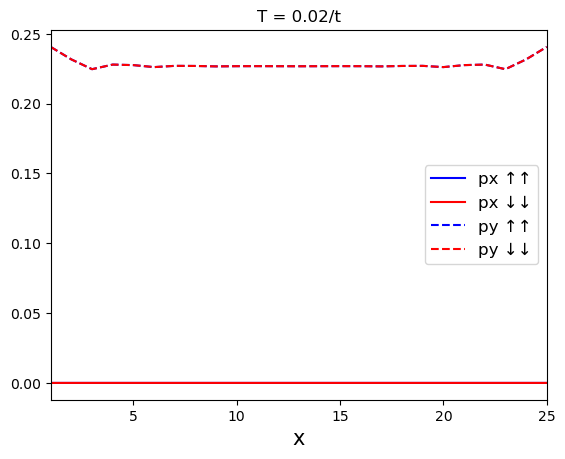

In [6]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
plt.plot(x, np.abs(Fuu.px), label="px ↑↑", color='blue')
plt.plot(x, np.abs(Fdd.px), label="px ↓↓", color='red')
plt.plot(x, np.abs(Fuu.py), "--", label="py ↑↑", color='blue')
plt.plot(x, np.abs(Fdd.py), "--", label="py ↓↓", color='red')
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")

In [14]:
X, Y = 10, 50
lattice = Lattice(X, Y)

t = 1
T = 0.01

muP = 1.8 * t
mu = np.ones(lattice.X) * muP

Bz = np.linspace(0, 2, 30)
Free_parr = np.zeros(len(Bz))
Free_narr = np.zeros(len(Bz))

U=None
V_prime=None
V=1.5 * np.ones(lattice.X)

for i, B in enumerate(Bz):
    hz = np.ones_like(mu) * B
    H_pwave = Hamiltonian(t, mu, lattice, 
                          U=None, V_prime=None, V=V,
                          F_init=[0.1, -0.1, 0.1j, -0.1j],
                          hz=hz)
    H_normal = Hamiltonian(t, mu, lattice, 
                           U=None, V_prime=None, V=None,
                           hz=hz)
    F_swave, F_dwave, F_px, F_py = bdg_sc(H_pwave, rtol=0.1, atol=1e-4, maxiter=1000, verbose=False, temperature=T)
    _, _, _, _ = bdg_sc(H_normal, rtol=0.1, atol=1e-4, maxiter=1000, verbose=False, temperature=T)

    Free_narr[i] = H_normal.free
    Free_parr[i] = H_pwave.free

Converged after 136 iterations
Converged after 1 iterations
Converged after 44 iterations
Converged after 1 iterations
Converged after 98 iterations
Converged after 1 iterations
Converged after 160 iterations
Converged after 1 iterations
Converged after 380 iterations
Converged after 1 iterations
Converged after 221 iterations
Converged after 1 iterations
Converged after 94 iterations
Converged after 1 iterations
Converged after 54 iterations
Converged after 1 iterations
Converged after 44 iterations
Converged after 1 iterations
Converged after 31 iterations
Converged after 1 iterations
Converged after 25 iterations
Converged after 1 iterations
Converged after 23 iterations
Converged after 1 iterations
Converged after 21 iterations
Converged after 1 iterations
Converged after 43 iterations
Converged after 1 iterations
Converged after 24 iterations
Converged after 1 iterations
Converged after 39 iterations
Converged after 1 iterations
Converged after 23 iterations
Converged after 1 iter

Text(0, 0.5, 'Free energy')

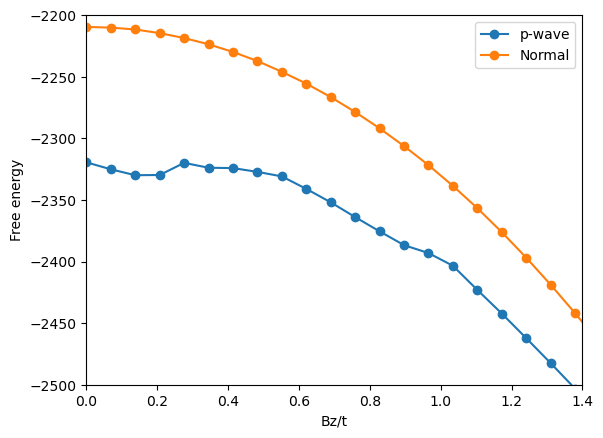

In [17]:
plt.plot(Bz, Free_parr, '-o', label="p-wave")
plt.plot(Bz, Free_narr, '-o', label="Normal")
plt.xlim(0, 1.4)
plt.ylim(-2500, -2200)
plt.legend()
plt.xlabel("Bz/t")
plt.ylabel("Free energy")

In [9]:
X, Y = 10, 50
lattice = Lattice(X, Y)

t = 1
T = 0.1

muP = 1.8 * t
mu = np.ones(lattice.X) * muP

Bz = np.linspace(0, 2, 30)
Free_parr = np.zeros(len(Bz))
Free_narr = np.zeros(len(Bz))

U=None
V_prime=None
V=1.5 * np.ones(lattice.X)

for i, B in enumerate(Bz):
    hz = np.ones_like(mu) * B
    H_pwave = Hamiltonian(t, mu, lattice, 
                          U=None, V_prime=None, V=V,
                          F_init=[0.1, -0.1, 0.1j, -0.1j],
                          hz=hz)
    H_normal = Hamiltonian(t, mu, lattice, 
                           U=None, V_prime=None, V=None,
                           hz=hz)
    F_swave, F_dwave, F_px, F_py = bdg_sc(H_pwave, rtol=0.01, atol=1e-6, maxiter=1000, verbose=False, temperature=T)
    _, _, _, _ = bdg_sc(H_normal, rtol=0.01, atol=1e-6, maxiter=1000, verbose=False, temperature=T)

    Free_narr[i] = H_normal.free
    Free_parr[i] = H_pwave.free

Converged after 184 iterations
Converged after 1 iterations
Converged after 158 iterations
Converged after 1 iterations
Converged after 140 iterations
Converged after 1 iterations
Converged after 899 iterations
Converged after 1 iterations
Converged after 802 iterations
Converged after 1 iterations
Converged after 254 iterations
Converged after 1 iterations
Converged after 141 iterations
Converged after 1 iterations
Converged after 94 iterations
Converged after 1 iterations
Converged after 67 iterations
Converged after 1 iterations
Converged after 54 iterations
Converged after 1 iterations
Converged after 47 iterations
Converged after 1 iterations
Converged after 40 iterations
Converged after 1 iterations
Converged after 41 iterations
Converged after 1 iterations
Converged after 47 iterations
Converged after 1 iterations
Converged after 52 iterations
Converged after 1 iterations
Converged after 83 iterations
Converged after 1 iterations
Converged after 45 iterations
Converged after 1 i

Text(0, 0.5, 'Free energy')

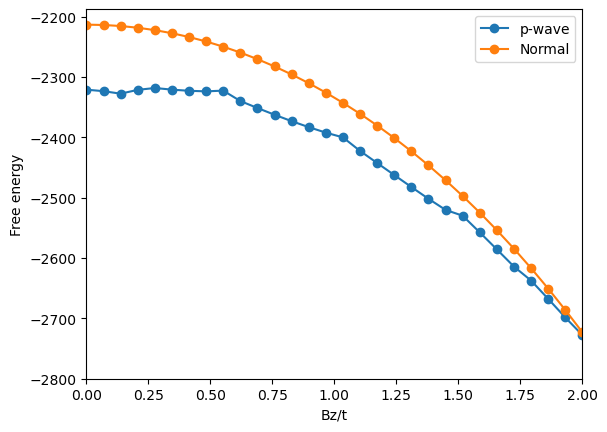

In [10]:
plt.plot(Bz, Free_parr, '-o', label="p-wave")
plt.plot(Bz, Free_narr, '-o', label="Normal")
plt.xlim(0, 2)
plt.ylim(-2800, None)
plt.legend()
plt.xlabel("Bz/t")
plt.ylabel("Free energy")

In [11]:
X, Y = 10, 50
lattice = Lattice(X, Y)

t = 1
T = 0.3

muP = 1.8 * t
mu = np.ones(lattice.X) * muP

Bz = np.linspace(0, 2, 30)
Free_parr = np.zeros(len(Bz))
Free_narr = np.zeros(len(Bz))

U=None
V_prime=None
V=1.5 * np.ones(lattice.X)

for i, B in enumerate(Bz):
    hz = np.ones_like(mu) * B
    H_pwave = Hamiltonian(t, mu, lattice, 
                          U=None, V_prime=None, V=V,
                          F_init=[0.1, -0.1, 0.1j, -0.1j],
                          hz=hz)
    H_normal = Hamiltonian(t, mu, lattice, 
                           U=None, V_prime=None, V=None,
                           hz=hz)
    F_swave, F_dwave, F_px, F_py = bdg_sc(H_pwave, rtol=0.01, atol=1e-6, maxiter=1000, verbose=False, temperature=T)
    _, _, _, _ = bdg_sc(H_normal, rtol=0.01, atol=1e-6, maxiter=1000, verbose=False, temperature=T)

    Free_narr[i] = H_normal.free
    Free_parr[i] = H_pwave.free

Converged after 1 iterations
Converged after 1 iterations
Converged after 1 iterations
Converged after 1 iterations
Converged after 279 iterations
Converged after 1 iterations
Converged after 159 iterations
Converged after 1 iterations
Converged after 183 iterations
Converged after 1 iterations
Converged after 312 iterations
Converged after 1 iterations
Converged after 190 iterations
Converged after 1 iterations
Converged after 234 iterations
Converged after 1 iterations
Converged after 187 iterations
Converged after 1 iterations
Converged after 173 iterations
Converged after 1 iterations
Converged after 182 iterations
Converged after 1 iterations
Converged after 214 iterations
Converged after 1 iterations
Converged after 264 iterations
Converged after 1 iterations
Converged after 301 iterations
Converged after 1 iterations
Converged after 287 iterations
Converged after 1 iterations
Converged after 282 iterations
Converged after 1 iterations
Converged after 340 iterations
Converged aft

Text(0, 0.5, 'Free energy')

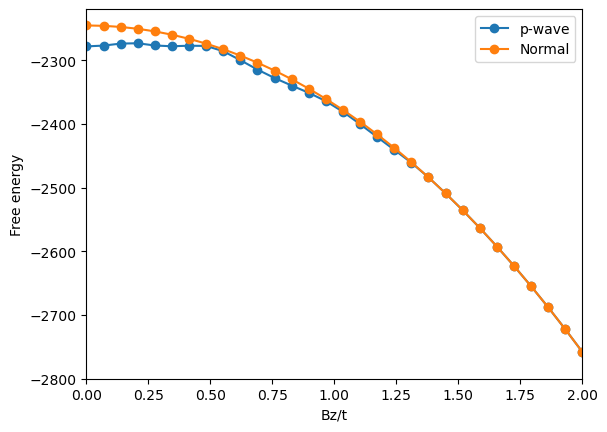

In [12]:
plt.plot(Bz, Free_parr, '-o', label="p-wave")
plt.plot(Bz, Free_narr, '-o', label="Normal")
plt.xlim(0, 2)
plt.ylim(-2800, None)
plt.legend()
plt.xlabel("Bz/t")
plt.ylabel("Free energy")